# 09 – Pivot Analysis

Ce notebook charge les artefacts `probabilities` générés par un run MLflow (cf. `08_modeling_point_total.ipynb`) et visualise la calibration des probabilités over/under pour chaque pivot. Ajuste les chemins ci-dessous pour pointer vers le run/ modèle que tu veux analyser.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.mlflow_utils import get_latest_run_dir

RUN_DIR = get_latest_run_dir(target="POINT_TOTAL", experiment_name="point_total_regression")


MODEL_KEY = "stacking"  # 'lgbm', 'xgb', 'ngboost', 'stacking'

summary_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / f"{MODEL_KEY}_pivot_summary.csv"
samples_path = RUN_DIR / "artifacts" / "probabilities" / MODEL_KEY / "samples" / f"{MODEL_KEY}_pivot_samples.csv"

summary_df = pd.read_csv(summary_path)
samples_df = pd.read_csv(samples_path)
samples_df["actual_over"] = (samples_df["actual"] > samples_df["pivot"]).astype(int)
samples_df["pred_over"] = samples_df["prob_over"]

display(summary_df.head())
display(samples_df.head())

,pivot,prob_under,prob_over
0,218.5,0.766173,0.233827
1,219.5,0.782329,0.217671
2,220.5,0.797857,0.202143
3,221.5,0.812736,0.187264
4,222.5,0.826955,0.173045


,prediction,actual,sigma,pivot,prob_under,prob_over,actual_over,pred_over
0,211.811963,229,15.731043,226.5,0.824770,0.175230,1,0.175230
1,217.066079,251,12.705280,242.5,0.977349,0.022651,1,0.022651
2,203.001262,195,15.829843,225.5,0.922383,0.077617,0,0.077617
3,216.239785,226,13.761083,232.5,0.881319,0.118681,0,0.118681
4,215.066492,210,16.725359,227.5,0.771378,0.228622,0,0.228622


## Calibration par pivot

,pivot,actual_over_rate,predicted_over,count
0,218.5,0.312500,0.254865,32
1,219.5,0.275000,0.204095,40
2,220.5,0.315789,0.203596,38
3,221.5,0.317073,0.190092,41
4,222.5,0.263158,0.148996,38
5,223.5,0.250000,0.158519,32
6,224.5,0.270833,0.193807,48
7,225.5,0.244444,0.137764,45
8,226.5,0.151515,0.115314,33
9,227.5,0.171429,0.093808,35


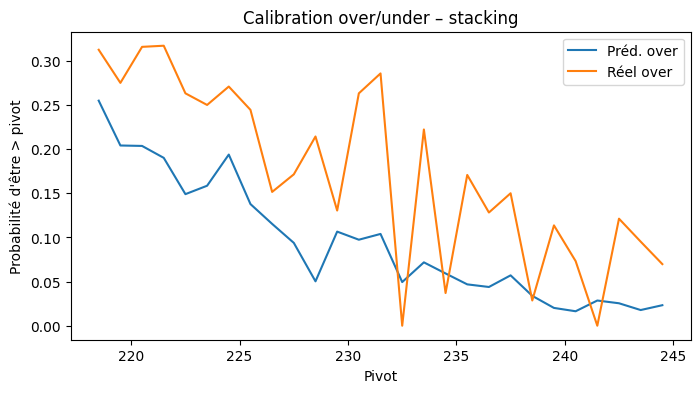

In [3]:
pivot_stats = (
    samples_df.groupby("pivot")
    .agg(
        actual_over_rate=("actual_over", "mean"),
        predicted_over=("pred_over", "mean"),
        count=("actual_over", "size"),
    )
    .reset_index()
)

display(pivot_stats)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pivot_stats["pivot"], pivot_stats["predicted_over"], label="Préd. over")
ax.plot(pivot_stats["pivot"], pivot_stats["actual_over_rate"], label="Réel over")
ax.set_xlabel("Pivot")
ax.set_ylabel("Probabilité d'être > pivot")
ax.legend()
ax.set_title(f"Calibration over/under – {MODEL_KEY}")
plt.show()

## Classement des pivots les plus "sûrs"

On calcule ci-dessous un score simple : distance entre la probabilité de dépassement et 0.5 (plus la probabilité est éloignée de 50 %, plus le modèle est confiant), pondéré par la différence entre la prédiction et la réalité.

In [4]:
samples_df["confidence"] = (samples_df["prob_over"] - 0.5).abs()
samples_df["hit"] = (samples_df["prob_over"] > 0.5) == (samples_df["actual"] > samples_df["pivot"])

top_edges = (
    samples_df.sort_values("confidence", ascending=False)
    [["prediction", "actual", "pivot", "prob_over", "prob_under", "confidence", "hit"]]
    .head(20)
)
display(top_edges)

,prediction,actual,pivot,prob_over,prob_under,confidence,hit
929,179.726357,159,237.5,5.238696e-09,1.000000,0.500000,True
343,192.131438,153,241.5,2.051935e-08,1.000000,0.500000,True
177,182.455124,170,239.5,2.066651e-08,1.000000,0.500000,True
732,186.000248,208,238.5,1.351923e-07,1.000000,0.500000,True
585,194.048400,210,242.5,1.841452e-07,1.000000,0.500000,True
788,190.246282,196,232.5,3.163109e-07,1.000000,0.500000,True
817,191.169287,191,238.5,6.723291e-07,0.999999,0.499999,True
8,186.238441,213,244.5,7.965279e-07,0.999999,0.499999,True
10,187.880306,204,236.5,1.104883e-06,0.999999,0.499999,True
499,188.100281,181,243.5,1.262096e-06,0.999999,0.499999,True


## Pivot bins (2 pts)

/tmp/ipykernel_550098/906336297.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_df.groupby('pivot_bin')


,pivot_bin,count,actual_over_rate,predicted_over
0,"[218.5, 221.5)",110,0.300000,0.218692
1,"[221.5, 224.5)",111,0.279279,0.166921
2,"[224.5, 227.5)",126,0.230159,0.153234
3,"[227.5, 230.5)",109,0.165138,0.088010
4,"[230.5, 233.5)",113,0.159292,0.079070
5,"[233.5, 236.5)",104,0.153846,0.058672
6,"[236.5, 239.5)",94,0.095745,0.042934
7,"[239.5, 242.5)",115,0.069565,0.020996
8,"[242.5, 245.5)",118,0.093220,0.021902


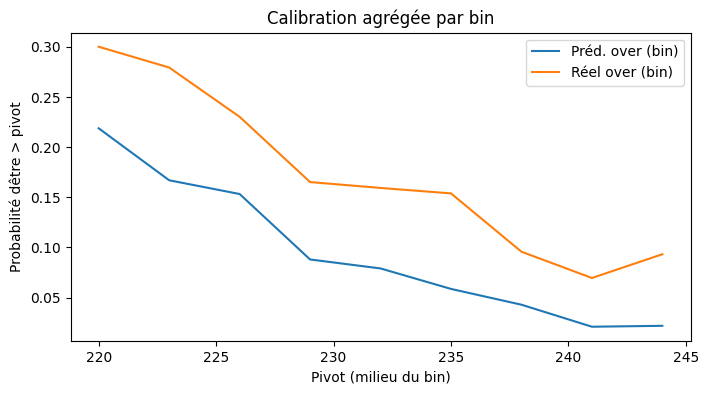

In [8]:
bin_edges = pd.interval_range(start=218.5, end=246.5, freq=3, closed='left')
samples_df['pivot_bin'] = pd.cut(samples_df['pivot'], bins=bin_edges)
bin_stats = (
    samples_df.groupby('pivot_bin')
    .agg(count=('actual_over','size'), actual_over_rate=('actual_over','mean'), predicted_over=('prob_over','mean'))
    .reset_index()
)
display(bin_stats)
if not bin_stats.empty:
    fig, ax = plt.subplots(figsize=(8,4))
    mids = bin_stats['pivot_bin'].apply(lambda x: x.mid if pd.notna(x) else pd.NA)
    ax.plot(mids, bin_stats['predicted_over'], label='Préd. over (bin)')
    ax.plot(mids, bin_stats['actual_over_rate'], label='Réel over (bin)')
    ax.set_xlabel('Pivot (milieu du bin)')
    ax.set_ylabel('Probabilité dêtre > pivot')
    ax.legend()
    ax.set_title('Calibration agrégée par bin')
    plt.show()


## Confiance vs taux de réussite

In [6]:
confidence_thresholds = [0.05, 0.1, 0.15, 0.2, 0.25]
records = []
for thresh in confidence_thresholds:
    subset = samples_df[samples_df['confidence'] >= thresh]
    hit_rate = subset['hit'].mean() if not subset.empty else float('nan')
    records.append({'threshold': thresh, 'count': len(subset), 'hit_rate': hit_rate})
confidence_df = pd.DataFrame(records)
display(confidence_df)


,threshold,count,hit_rate
0,0.05,975,0.841026
1,0.10,951,0.846477
2,0.15,929,0.854682
3,0.20,898,0.860802
4,0.25,866,0.870670


## Distribution des sigma

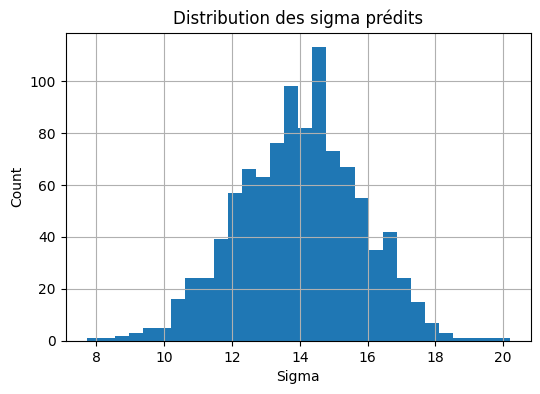

In [7]:
if 'sigma' in samples_df.columns:
    fig, ax = plt.subplots(figsize=(6,4))
    samples_df['sigma'].hist(bins=30, ax=ax)
    ax.set_title('Distribution des sigma prédits')
    ax.set_xlabel('Sigma')
    ax.set_ylabel('Count')
    plt.show()
else:
    print('Colonne sigma absente du fichier samples.')
